# Análisis Exploratorio de Datos (EDA) - Abandono de Clientes

Este cuaderno contiene un análisis detallado del dataset `telecom_churn.csv` con el objetivo de entender los factores que influyen en el abandono de clientes (churn) y visualizar posibles desequilibrios en los datos.

## 1. Configuración del Entorno

Importamos las librerías necesarias para el análisis y la visualización.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo para las gráficas
sns.set(style="whitegrid")
%matplotlib inline

## 2. Carga de Datos

Cargamos el dataset y realizamos una primera inspección visual.

In [2]:
df = pd.read_csv('telecom_churn.csv')
df.head()

,Churn,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
0,0,128,1,1,2.7,1,265.1,110,89.0,9.87,10.0
1,0,107,1,1,3.7,1,161.6,123,82.0,9.78,13.7
2,0,137,1,0,0.0,0,243.4,114,52.0,6.06,12.2
3,0,84,0,0,0.0,2,299.4,71,57.0,3.10,6.6
4,0,75,0,0,0.0,3,166.7,113,41.0,7.42,10.1


## 3. Información Básica del Dataset

Revisamos los tipos de datos, valores no nulos y estadísticas descriptivas.

In [3]:
print("Información general:")
df.info()

print("\nEstadísticas descriptivas:")
display(df.describe())

Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Churn            3333 non-null   int64  
 1   AccountWeeks     3333 non-null   int64  
 2   ContractRenewal  3333 non-null   int64  
 3   DataPlan         3333 non-null   int64  
 4   DataUsage        3333 non-null   float64
 5   CustServCalls    3333 non-null   int64  
 6   DayMins          3333 non-null   float64
 7   DayCalls         3333 non-null   int64  
 8   MonthlyCharge    3333 non-null   float64
 9   OverageFee       3333 non-null   float64
 10  RoamMins         3333 non-null   float64
dtypes: float64(5), int64(6)
memory usage: 286.6 KB

Estadísticas descriptivas:


,Churn,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
count,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000
mean,0.144914,101.064806,0.903090,0.276628,0.816475,1.562856,179.775098,100.435644,56.305161,10.051488,10.237294
std,0.352067,39.822106,0.295879,0.447398,1.272668,1.315491,54.467389,20.069084,16.426032,2.535712,2.791840
min,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,0.000000,0.000000
25%,0.000000,74.000000,1.000000,0.000000,0.000000,1.000000,143.700000,87.000000,45.000000,8.330000,8.500000
50%,0.000000,101.000000,1.000000,0.000000,0.000000,1.000000,179.400000,101.000000,53.500000,10.070000,10.300000
75%,0.000000,127.000000,1.000000,1.000000,1.780000,2.000000,216.400000,114.000000,66.200000,11.770000,12.100000
max,1.000000,243.000000,1.000000,1.000000,5.400000,9.000000,350.800000,165.000000,111.300000,18.190000,20.000000


## 4. Análisis de Valores Nulos

Verificamos si existen valores faltantes en el dataset.

In [4]:
null_counts = df.isnull().sum()
print("Valores nulos por columna:")
print(null_counts[null_counts > 0] if null_counts.any() else "No hay valores nulos.")

Valores nulos por columna:
No hay valores nulos.


## 5. Análisis del Desbalanceo de Clase (Churn)

Es crucial verificar si los datos están balanceados, ya que un desequilibrio significativo puede afectar el rendimiento de los modelos de clasificación.

Conteo de clases:
Churn
0    2850
1     483
Name: count, dtype: int64

Porcentaje de clases:
Churn
0    85.508551
1    14.491449
Name: proportion, dtype: float64


C:\Users\cnava\AppData\Local\Temp\ipykernel_14224\3688606432.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, ax=ax[0], palette='viridis')


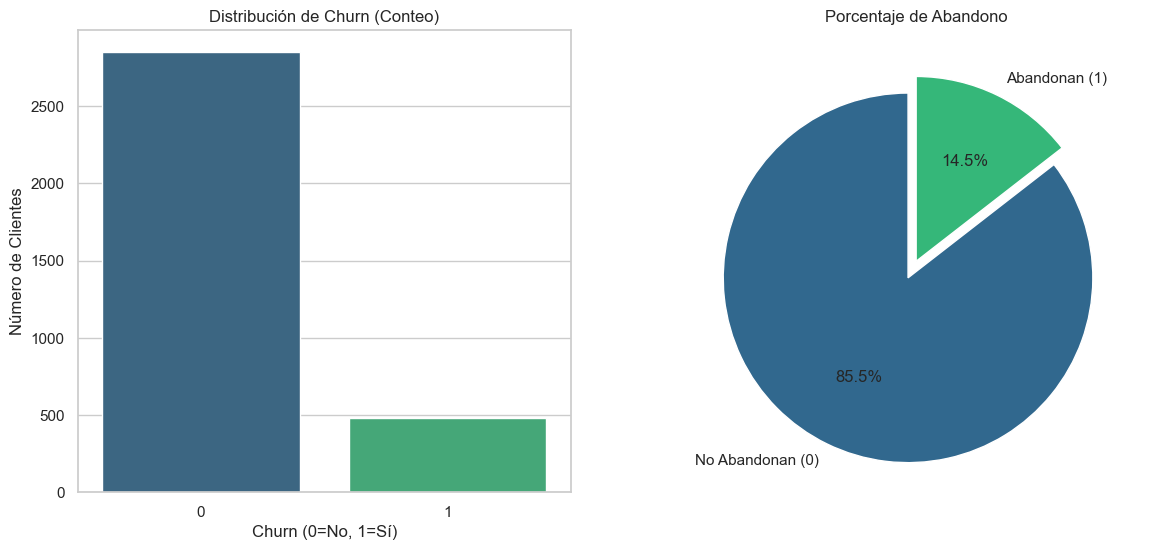

In [5]:
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

print("Conteo de clases:")
print(churn_counts)
print("\nPorcentaje de clases:")
print(churn_pct)

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Gráfica de barras
sns.countplot(x='Churn', data=df, ax=ax[0], palette='viridis')
ax[0].set_title('Distribución de Churn (Conteo)')
ax[0].set_xlabel('Churn (0=No, 1=Sí)')
ax[0].set_ylabel('Número de Clientes')

# Gráfica de tarta
ax[1].pie(churn_counts, labels=['No Abandonan (0)', 'Abandonan (1)'], autopct='%1.1f%%', 
        startangle=90, colors=sns.color_palette('viridis', 2), explode=(0.1, 0))
ax[1].set_title('Porcentaje de Abandono')

plt.show()

## 6. Correlación entre Variables

Analizamos cómo se relacionan las variables entre sí mediante una matriz de correlación.

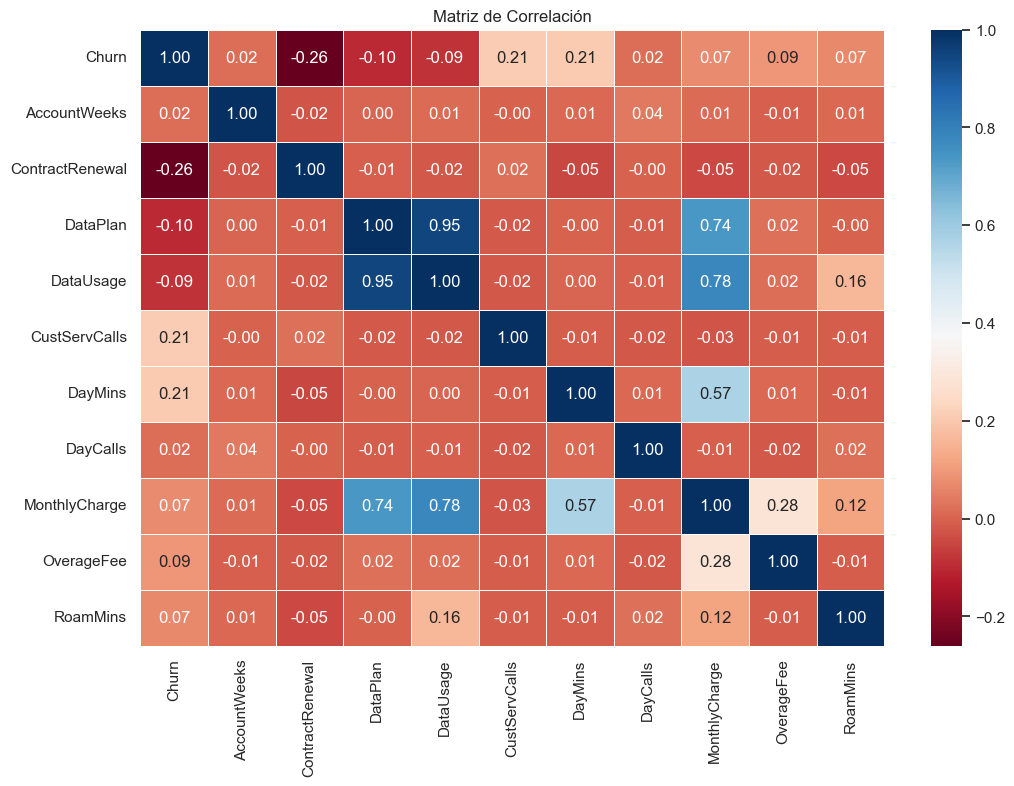

In [6]:
plt.figure(figsize=(12, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu', fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlación')
plt.show()

## 7. Análisis de Características vs Churn

Exploramos cómo algunas variables clave se comportan respecto al abandono.

C:\Users\cnava\AppData\Local\Temp\ipykernel_14224\1854469861.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='CustServCalls', data=df, ax=ax[0, 0], palette='magma')
C:\Users\cnava\AppData\Local\Temp\ipykernel_14224\1854469861.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='MonthlyCharge', data=df, ax=ax[0, 1], palette='magma')


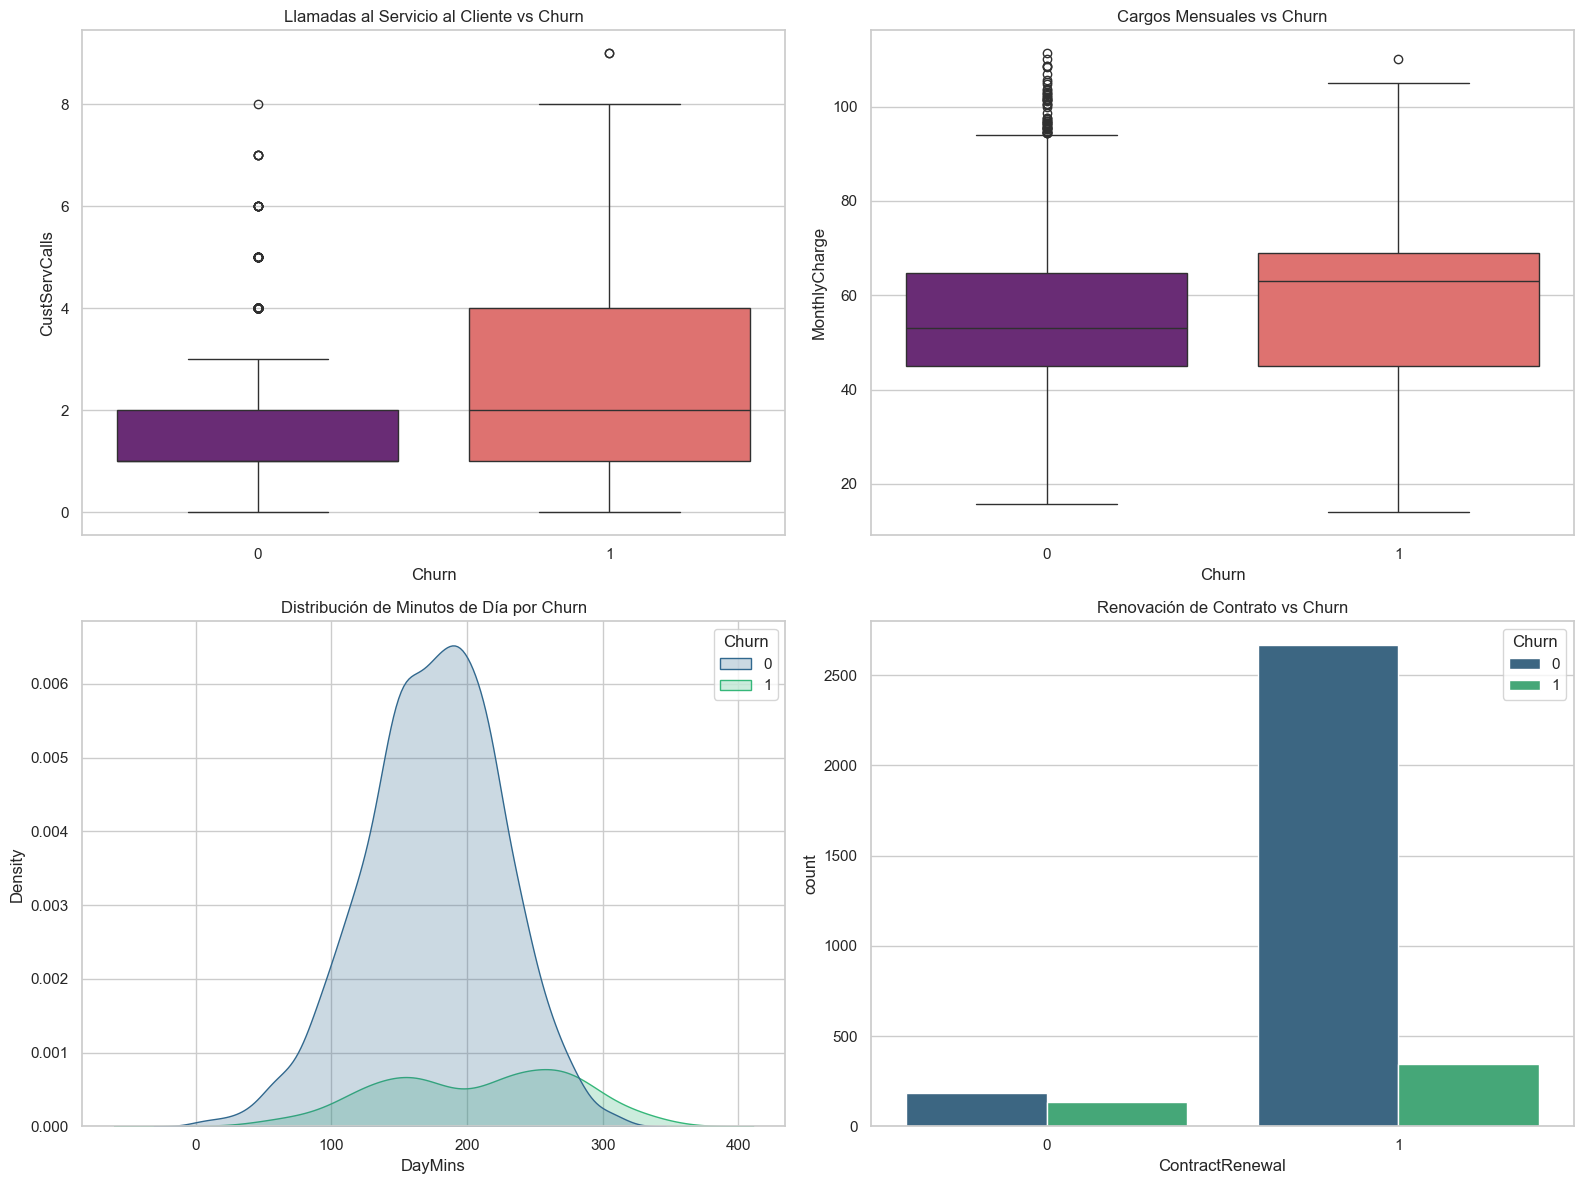

In [7]:
fig, ax = plt.subplots(2, 2, figsize=(16, 12))

# Llamadas al servicio al cliente
sns.boxplot(x='Churn', y='CustServCalls', data=df, ax=ax[0, 0], palette='magma')
ax[0, 0].set_title('Llamadas al Servicio al Cliente vs Churn')

# Cargos mensuales
sns.boxplot(x='Churn', y='MonthlyCharge', data=df, ax=ax[0, 1], palette='magma')
ax[0, 1].set_title('Cargos Mensuales vs Churn')

# Minutos de día
sns.kdeplot(data=df, x='DayMins', hue='Churn', fill=True, ax=ax[1, 0], palette='viridis')
ax[1, 0].set_title('Distribución de Minutos de Día por Churn')

# Renovación de Contrato
sns.countplot(x='ContractRenewal', hue='Churn', data=df, ax=ax[1, 1], palette='viridis')
ax[1, 1].set_title('Renovación de Contrato vs Churn')

plt.tight_layout()
plt.show()

## 8. Conclusiones Directas del EDA

1. **Desbalanceo**: Los datos están significativamente desbalanceados (~14.5% churn vs ~85.5% no churn). Esto debe tenerse en cuenta al entrenar modelos.
2. **Servicio al Cliente**: Los clientes que abandonan suelen tener un mayor número de llamadas al servicio al cliente.
3. **Cargos y Uso**: Tanto los cargos mensuales como los minutos de uso durante el día parecen ser indicadores relevantes, con valores más altos generalmente asociados a un mayor churn.
4. **Contrato**: El no renovar el contrato (`ContractRenewal=0`) tiene una relación visual clara con el abandono.